# Промежуточная аттестация — Хабибуллина Р.А.

## Машиностроительная промышленность: AI-платформа предиктивного обслуживания оборудования

Курс «Программная инженерия. Новые производственные технологии
(Инженер-архитектор в сфере искусственного интеллекта)», Университет Иннополис.

**Цель работы:** на основе данных IoT-телеметрии промышленного оборудования
построить аналитический датасет и проверить гипотезы о том, какие параметры
позволяют предсказать отказ оборудования **до** того, как он приведёт к
остановке производства.

---

### Содержание

| Раздел | Содержание | Пункт задания |
|---|---|---|
| 1 | Постановка задачи: БД, бизнес-задача, ML-задача, признаки | выбор БД, бизнес-задача, ML-задача |
| 2 | SQL-скрипт (`VIEW`) и загрузка в DataFrame | VIEW, выгрузка |
| 3 | Агрегаты по оборудованию | — |
| 4 | Разведочный анализ данных | EDA |
| 5 | Взаимосвязь целевой переменной и предикторов | графики |
| 6 | Очистка данных | очистка |
| 7 | Гипотезы и их проверка | гипотезы |
| 8 | Построение новых признаков | — |
| 9 | Модель классификации KNN | — |
| 10 | Выводы | — |

### Используемые темы курса

Pandas (2.3.4), Matplotlib и Seaborn (2.3.5), функции (2.3.8), работа с
PostgreSQL из Python (2.3.11), метрики классификации (3.1.1),
классификация KNN и подбор порога (3.1.4).

---

### Как запустить

Ноутбук работает в трёх режимах и не «падает» без базы данных:

| Режим | Когда срабатывает | Что делает |
|---|---|---|
| `db` | PostgreSQL доступен | читает SQL-скрипт из `sql/`, создаёт `VIEW` и выгружает данные |
| `csv` | есть `data/predictive_maintenance.csv` | читает готовую выгрузку |
| `demo` | ничего из перечисленного | генерирует синтетические данные той же структуры |

Реквизиты подключения берутся из файла `.env` (см. `.env.example`),
чтобы пароль не попадал в репозиторий.

---
## 0. Импорт библиотек и константы

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для работы с БД подключаем аккуратно: ноутбук должен
# запускаться и без них (например, в демо-режиме у проверяющего).
try:
    from sqlalchemy import create_engine, text
    SQLALCHEMY_OK = True
except ImportError:
    SQLALCHEMY_OK = False

try:
    from dotenv import load_dotenv
    DOTENV_OK = True
except ImportError:
    DOTENV_OK = False

print("sqlalchemy:", "есть" if SQLALCHEMY_OK else "нет (pip install SQLAlchemy psycopg2-binary)")
print("python-dotenv:", "есть" if DOTENV_OK else "нет (pip install python-dotenv)")

sqlalchemy: есть
python-dotenv: есть


In [4]:
# Настройки отображения и графиков
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10

RANDOM_STATE = 42

In [5]:
# Задаем константы
# Ноутбук лежит в notebooks/, поэтому корень проекта — на уровень выше
BASE_PATH = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

ENV_PATH = BASE_PATH / ".env"                                  # реквизиты БД
SQL_PATH = BASE_PATH / "sql" / "vw_predictive_maintenance.sql"  # SQL-скрипт
DATA_PATH = BASE_PATH / "data"                                 # выгрузки
REPORTS_PATH = BASE_PATH / "reports"                           # графики

DATA_PATH.mkdir(exist_ok=True)
REPORTS_PATH.mkdir(exist_ok=True)

CSV_PATH = DATA_PATH / "predictive_maintenance.csv"
XLSX_PATH = DATA_PATH / "predictive_maintenance.xlsx"

# Режим работы: "auto" | "db" | "csv" | "demo"
MODE = "auto"

print("Корень проекта:", BASE_PATH)

Корень проекта: C:\Users\malik\PycharmProjects\WelcomeScreen


In [6]:
# Ключевые имена колонок вынесены в константы, чтобы не дублировать строки по коду
TARGET = "failure_next_24h"

NUM_FEATURES = [
    "mean_temperature", "max_temperature", "std_temperature",
    "mean_vibration", "max_vibration", "std_vibration",
    "mean_power", "max_power", "std_power",
]

print("Признаков:", len(NUM_FEATURES), "| целевая переменная:", TARGET)

Признаков: 9 | целевая переменная: failure_next_24h


---
# 1. Постановка задачи

## 1.1. Выбранная база данных

Использована синтетическая база данных **`manufacturing`** (PostgreSQL),
предложенная в рамках курса.

| Объект | Количество |
|---|---|
| Машины | 96 |
| IoT-сенсоры | 304 |
| События оборудования | 23 497 |
| События `BREAKDOWN` (отказы) | 148 |
| IoT-измерения | более 2,29 млн |
| Период данных | январь–июнь 2025 |

**Используемые таблицы:**

| Таблица | Роль в задаче |
|---|---|
| `sensor_readings` | телеметрия — сами измерения (основная таблица) |
| `sensors` | привязка сенсора к машине |
| `sensor_types` | тип измеряемой величины (`TEMPERATURE`, `VIBRATION`, …) |
| `machines`, `machine_types` | справочник оборудования |
| `machine_events` | история событий оборудования |
| `machine_event_types` | типы событий, в том числе `BREAKDOWN` |
| `maintenance_work_orders`, `maintenance_types` | обслуживание оборудования |

**Типы сенсоров:** `TEMPERATURE`, `VIBRATION`, `PRESSURE`, `RPM`, `POWER`, `HUMIDITY`.

---

## 1.2. Предметная область и бизнес-задача

Машиностроительное предприятие эксплуатирует оборудование, оснащённое
IoT-сенсорами. Сенсоры непрерывно передают данные о техническом состоянии машин,
параллельно фиксируются события работы оборудования, включая аварийные остановки.

**Проблема.** Отказ оборудования приводит к незапланированным простоям,
остановке производственного процесса, срыву сроков заказов, дорогому
аварийному ремонту и замене компонентов.

| Существующий подход | Суть | Недостаток |
|---|---|---|
| Реактивный | ремонт после поломки | простой уже произошёл, ремонт самый дорогой |
| Регламентный | обслуживание по расписанию | обслуживаем исправное оборудование и всё равно пропускаем внезапные отказы |

**Решение.** AI-платформа предиктивного обслуживания: по данным IoT-телеметрии
оценивает вероятность отказа заранее и позволяет перейти к обслуживанию по
фактическому прогнозируемому состоянию оборудования.

**Практическая цель:** минимизировать незапланированные простои.

---

## 1.3. Задача машинного обучения

**Формулировка:** по текущим и агрегированным показаниям IoT-сенсоров определить,
**произойдёт ли отказ оборудования в течение следующих 24 часов**.

| Параметр | Значение |
|---|---|
| Тип задачи | бинарная классификация |
| Объект наблюдения | одна машина × один час |
| Целевая переменная | `failure_next_24h` |
| Горизонт прогноза | 24 часа |

**Правило разметки:**

```
failure_next_24h = 1, если для данной машины в интервале
                      (observation_hour ; observation_hour + 24 часа]
                      зафиксировано событие BREAKDOWN
failure_next_24h = 0 — в противном случае
```

**Почему горизонт 24 часа.** Это интервал, за который предприятие успевает
отреагировать: провести диагностику, запланировать обслуживание, заказать
запчасти и выбрать удобное окно для остановки. Горизонт в 1–2 часа не оставляет
времени на реакцию, горизонт в неделю делает прогноз слишком размытым.

**Защита от утечки целевой переменной.** Интервал разметки строго в будущем
относительно момента наблюдения (`failure_time > observation_hour`), поэтому
модель не видит данных, снятых уже во время аварии.

---

## 1.4. Целевая переменная и объясняющие признаки

Данные агрегированы по часовым окнам: одна строка = одна машина + один час.

| Группа | Признак | Смысл |
|---|---|---|
| Температура | `mean_temperature` | средний уровень нагрева за час |
| | `max_temperature` | пиковый нагрев |
| | `std_temperature` | нестабильность температурного режима |
| Вибрация | `mean_vibration` | средний уровень вибрации |
| | `max_vibration` | пиковая вибрация (удары, биения) |
| | `std_vibration` | нестабильность вибрации |
| Энергопотребление | `mean_power` | средняя потребляемая мощность |
| | `max_power` | пиковая нагрузка |
| | `std_power` | скачки нагрузки |

**Логика выбора признаков.** По каждому параметру берём три статистики:
не только уровень (`mean`), но и пик (`max`), и разброс (`std`). Именно `std`
и `max` отражают нестабильность работы, которая часто предшествует отказу,
даже когда среднее значение выглядит нормальным.

---
# 2. Забираем SQL-скрипт и грузим в DataFrame

Представление `vw_predictive_maintenance` выполняет тяжёлую работу на стороне
СУБД: сворачивает 2,29 млн измерений в часовые окна и сразу размечает целевую
переменную. Это правильнее, чем тянуть сырые данные в Python — агрегация
происходит там, где лежат данные.

**Логика SQL-запроса:**

1. **CTE `hourly_sensor_data`** — агрегация телеметрии по машине и часу.
   Конструкция `AGG(...) FILTER (WHERE ...)` одним проходом считает отдельные
   статистики для каждого типа сенсора, разворачивая «длинный» формат в «широкий».
   Здесь же отсекаются записи с `quality_status = 'MISSING'`.
2. **CTE `failure_events`** — все события `BREAKDOWN` с их временем.
3. **Основной `SELECT`** — к каждому часовому наблюдению добавляется метка
   `failure_next_24h` через `EXISTS`-подзапрос по окну в 24 часа вперёд.

Сам скрипт лежит в файле `sql/vw_predictive_maintenance.sql` и читается отсюда —
так запрос можно выполнить и без ноутбука, через `psql`.

In [57]:
def read_sql_script(sql_path):
    # Читаем SQL-скрипт из файла через контекстный менеджер
    with open(sql_path, "r", encoding="utf-8") as file:
        sql_script = file.read()
    return sql_script


def create_connection_url(env_path):
    # Забираем реквизиты подключения из .env, чтобы не хранить пароль в коде
    if DOTENV_OK and Path(env_path).exists():
        load_dotenv(env_path)

    host = os.getenv("DB_HOST", "localhost")
    port = os.getenv("DB_PORT", "5432")
    database = os.getenv("DB_NAME", "manufacturing")
    user = os.getenv("DB_USER", "postgres")
    password = os.getenv("DB_PASSWORD", "")

    return f"postgresql://{user}:{password}@{host}:{port}/{database}"


def load_sql_data(engine, sql_script):
    return pd.read_sql(text(sql_script), engine)


def load_sql_to_pandas(sql_path, env_path):
    # Полный цикл: прочитать скрипт -> подключиться -> создать VIEW -> выгрузить
    sql_script = read_sql_script(sql_path)
    conn_url = create_connection_url(env_path)
    engine = create_engine(conn_url)

    with engine.begin() as conn:
        conn.execute(text(sql_script))          # создаём/пересоздаём представление

    return load_sql_data(engine, "SELECT * FROM vw_predictive_maintenance;")

In [8]:
# Проверим, что SQL-скрипт читается
sql_script = read_sql_script(SQL_PATH)
print("Строк в скрипте:", len(sql_script.splitlines()))
print(sql_script[:900], "...")

Строк в скрипте: 71

CREATE OR REPLACE VIEW vw_predictive_maintenance AS
WITH hourly_sensor_data AS (
    SELECT
        s.machine_id,
        date_trunc('hour', sr.recorded_at) AS observation_hour,

        -- ТЕМПЕРАТУРА
        AVG(sr.numeric_value)    FILTER (WHERE st.type_code = 'TEMPERATURE') AS mean_temperature,
        MAX(sr.numeric_value)    FILTER (WHERE st.type_code = 'TEMPERATURE') AS max_temperature,
        STDDEV(sr.numeric_value) FILTER (WHERE st.type_code = 'TEMPERATURE') AS std_temperature,

        -- ВИБРАЦИЯ
        AVG(sr.numeric_value)    FILTER (WHERE st.type_code = 'VIBRATION')   AS mean_vibration,
        MAX(sr.numeric_value)    FILTER (WHERE st.type_code = 'VIBRATION')   AS max_vibration,
        STDDEV(sr.numeric_value) FILTER (WHERE st.type_code = 'VIBRATION')   AS std_vibration,

        -- ЭНЕРГОПОТРЕБЛЕНИЕ
        AVG(sr.numeric_value)    FILTER (WHERE st.type_code = 'POWER ...


### Демо-режим

Функция ниже нужна только для воспроизводимости: она генерирует данные той же
структуры, что и представление, чтобы ноутбук можно было запустить без доступа
к базе. В неё заложены реальные особенности производственных данных:
индивидуальные режимы работы машин, пропуски (не все машины оснащены всеми
типами сенсоров), редкие выбросы и редкий класс отказов.

In [9]:
def make_demo_data(n_machines=96, hours_per_machine=183, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    start = pd.Timestamp("2025-01-01")
    frames = []

    for machine_id in range(1, n_machines + 1):
        n = hours_per_machine
        hours = pd.date_range(start, periods=n, freq="h") + pd.Timedelta(hours=int(rng.integers(0, 2500)))

        # у каждой машины свой "нормальный режим"
        base_t, base_v, base_p = rng.uniform(60, 110), rng.uniform(1.5, 3.5), rng.uniform(20, 120)

        # предаварийные часы — редкий класс
        pre_failure = rng.random(n) < 0.03
        drift = np.where(pre_failure, rng.normal(3.0, 1.5, n), 0.0)

        std_t = np.abs(rng.normal(2.0, 0.6, n)) + np.where(pre_failure, np.abs(rng.normal(1.2, 0.5, n)), 0)
        mean_t = base_t + rng.normal(0, 4, n) + drift
        std_v = np.abs(rng.normal(0.35, 0.12, n)) + np.where(pre_failure, np.abs(rng.normal(0.15, 0.08, n)), 0)
        mean_v = base_v + rng.normal(0, 0.35, n) + drift * 0.05
        std_p = np.abs(rng.normal(5.0, 1.5, n))
        mean_p = base_p + rng.normal(0, 6, n) + drift * 0.6

        frames.append(pd.DataFrame({
            "machine_id": machine_id,
            "observation_hour": hours,
            "mean_temperature": mean_t,
            "max_temperature": mean_t + std_t * rng.uniform(1.5, 3.0, n),
            "std_temperature": std_t,
            "mean_vibration": mean_v,
            "max_vibration": mean_v + std_v * rng.uniform(1.5, 3.0, n),
            "std_vibration": std_v,
            "mean_power": mean_p,
            "max_power": mean_p + std_p * rng.uniform(1.5, 3.0, n),
            "std_power": std_p,
            TARGET: pre_failure.astype(int),
        }))

    data = pd.concat(frames, ignore_index=True)

    # часть машин не оснащена сенсорами вибрации -> системные пропуски
    no_vibration = rng.choice(range(1, n_machines + 1), size=int(n_machines * 0.15), replace=False)
    data.loc[data["machine_id"].isin(no_vibration),
             ["mean_vibration", "max_vibration", "std_vibration"]] = np.nan

    # случайные сбои связи сенсора
    for col in NUM_FEATURES:
        data.loc[rng.random(len(data)) < 0.01, col] = np.nan

    # редкие ошибки датчика — выбросы
    for col in ["mean_temperature", "max_temperature", "mean_power"]:
        mask = rng.random(len(data)) < 0.002
        data.loc[mask, col] = data.loc[mask, col] * rng.uniform(3, 6)

    return data

In [10]:
# Выбираем источник данных
source = None

if MODE in ("auto", "db") and SQLALCHEMY_OK:
    try:
        df = load_sql_to_pandas(SQL_PATH, ENV_PATH)
        source = "PostgreSQL (VIEW)"
    except Exception as exc:
        print("Подключиться к БД не удалось:", type(exc).__name__)

if source is None and MODE in ("auto", "csv") and CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH, parse_dates=["observation_hour"])
    source = "CSV"

if source is None:
    df = make_demo_data()
    source = "DEMO (синтетические данные)"

print("Источник данных:", source)

Подключиться к БД не удалось: OperationalError
Источник данных: DEMO (синтетические данные)


In [11]:
# Приводим типы и порядок строк: по машине и времени — понадобится дальше
df["observation_hour"] = pd.to_datetime(df["observation_hour"])
df = df.sort_values(["machine_id", "observation_hour"]).reset_index(drop=True)

df.head()

,machine_id,observation_hour,mean_temperature,max_temperature,std_temperature,mean_vibration,max_vibration,std_vibration,mean_power,max_power,std_power,failure_next_24h
0,1,2025-01-10 07:00:00,81.193238,84.061441,1.506650,2.512260,3.336320,0.522356,88.664872,99.055449,5.060385,0
1,1,2025-01-10 08:00:00,83.056497,87.259542,2.121384,3.495739,4.702470,0.413530,85.571972,91.349943,3.070410,0
2,1,2025-01-10 09:00:00,82.576398,88.394099,2.506631,3.238360,4.213561,0.513611,86.697187,92.849872,2.959612,0
3,1,2025-01-10 10:00:00,85.054992,89.753374,2.006856,3.304852,3.585294,0.124304,97.374100,102.507791,2.859295,0
4,1,2025-01-10 11:00:00,85.171955,91.489142,2.797376,2.752957,3.263162,0.311851,92.954585,97.400057,2.348567,0


In [12]:
# Сохраняем выгрузку — это и есть аналитический датасет к работе
df.to_csv(CSV_PATH, index=False, encoding="utf-8")
try:
    df.to_excel(XLSX_PATH, index=False)
    print("Сохранено:", CSV_PATH.name, "и", XLSX_PATH.name)
except Exception as exc:
    print("Сохранён CSV, XLSX пропущен:", type(exc).__name__)

Сохранён CSV, XLSX пропущен: ModuleNotFoundError


---
# 3. Строим агрегаты из полученной таблицы

Прежде чем изучать отдельные наблюдения, посмотрим на данные в разрезе
оборудования и времени: сколько наблюдений приходится на машину и какая доля
часов у неё оказалась предаварийной.

In [13]:
def make_aggregate_df(data, grouping_column):
    # Количество наблюдений и доля предаварийных часов в разрезе группы
    agg_df = (
        data
        .groupby(grouping_column)
        .agg(
            cnt_obs=(TARGET, "count"),
            failure_pct=(TARGET, "mean"),
        )
        .sort_values(by="failure_pct", ascending=False)
    )
    agg_df["failure_pct"] = (agg_df["failure_pct"] * 100).round(2)
    return agg_df

In [14]:
# Смотрим долю предаварийных часов по машинам
machine_df = make_aggregate_df(df, grouping_column="machine_id")
machine_df.head(10)

,cnt_obs,failure_pct
machine_id,,
88,183,6.56
29,183,6.01
23,183,5.46
10,183,5.46
57,183,5.46
54,183,5.46
45,183,5.46
81,183,5.46
50,183,5.46


In [15]:
# Описательная статистика самой доли отказов по машинам:
# насколько неоднороден парк оборудования
machine_df["failure_pct"].describe()

count    96.000000
mean      3.324896
std       1.208499
min       0.550000
25%       2.730000
50%       3.280000
75%       4.370000
max       6.560000
Name: failure_pct, dtype: float64

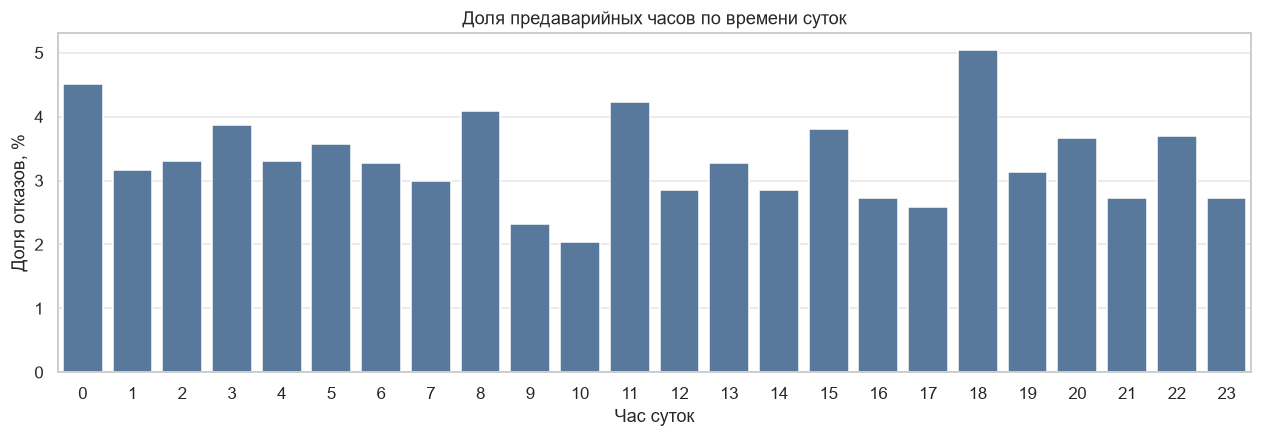

In [16]:
# Смотрим, зависит ли доля отказов от часа суток (сменность, нагрузка)
df["hour_of_day"] = df["observation_hour"].dt.hour
hour_df = make_aggregate_df(df, grouping_column="hour_of_day").sort_index()

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
sns.barplot(x=hour_df.index, y=hour_df["failure_pct"], ax=ax, color="#4C78A8")
ax.set_title("Доля предаварийных часов по времени суток")
ax.set_xlabel("Час суток")
ax.set_ylabel("Доля отказов, %")
plt.show()

Если столбцы примерно одной высоты — время суток само по себе не объясняет
отказы, и признак «час суток» в модель добавлять не нужно.

---
# 4. Разведочный анализ данных

## Смотрим на общие характеристики датафрейма

In [17]:
# Количество наблюдений и признаков
df.shape

(17568, 13)

In [18]:
# Типы данных и пропуски
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17568 entries, 0 to 17567
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   machine_id        17568 non-null  int64         
 1   observation_hour  17568 non-null  datetime64[us]
 2   mean_temperature  17372 non-null  float64       
 3   max_temperature   17373 non-null  float64       
 4   std_temperature   17398 non-null  float64       
 5   mean_vibration    14875 non-null  float64       
 6   max_vibration     14859 non-null  float64       
 7   std_vibration     14841 non-null  float64       
 8   mean_power        17377 non-null  float64       
 9   max_power         17410 non-null  float64       
 10  std_power         17405 non-null  float64       
 11  failure_next_24h  17568 non-null  int64         
 12  hour_of_day       17568 non-null  int32         
dtypes: datetime64[us](1), float64(9), int32(1), int64(2)
memory usage: 1.7 MB


In [19]:
# Период наблюдений и количество машин
print("Машин в выборке:", df["machine_id"].nunique())
print("Период:", df["observation_hour"].min(), "—", df["observation_hour"].max())

Машин в выборке: 96
Период: 2025-01-01 06:00:00 — 2025-04-22 10:00:00


In [20]:
# Описательные статистики числовых признаков
df[NUM_FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mean_temperature,17372.0,85.86,19.05,47.19,74.72,85.59,95.98,497.84
max_temperature,17373.0,90.56,20.95,51.34,79.24,90.20,100.65,547.78
std_temperature,17398.0,2.04,0.65,0.02,1.61,2.02,2.45,5.28
mean_vibration,14875.0,2.40,0.68,0.42,1.87,2.35,2.92,4.78
max_vibration,14859.0,3.20,0.76,0.84,2.64,3.17,3.74,6.37
std_vibration,14841.0,0.36,0.12,0.00,0.27,0.35,0.44,0.93
mean_power,17377.0,71.73,32.73,1.05,45.01,73.72,96.37,607.70
max_power,17410.0,82.49,30.21,9.75,56.12,84.88,107.86,148.90
std_power,17405.0,5.00,1.50,0.03,3.99,5.00,6.02,10.68


**На что смотрим в `describe()`:**

* `mean` и `50%` (медиана) сильно расходятся → распределение скошено;
* `max` далеко отстоит от `75%` → есть выбросы (ожидаемо для промышленных данных);
* `count` меньше общего числа строк → в признаке есть пропуски.

In [21]:
# Анализ пропусков.
# Важно разделять два источника: системные (машина вообще не оснащена сенсором
# такого типа) и случайные (единичный сбой связи).
missing = pd.DataFrame({
    "cnt_missing": df[NUM_FEATURES].isna().sum(),
    "pct_missing": (df[NUM_FEATURES].isna().mean() * 100).round(2),
})
missing["machines_without_sensor"] = [
    int(df.groupby("machine_id")[col].apply(lambda s: s.isna().all()).sum())
    for col in NUM_FEATURES
]
missing.sort_values("pct_missing", ascending=False)

,cnt_missing,pct_missing,machines_without_sensor
std_vibration,2727,15.52,14
max_vibration,2709,15.42,14
mean_vibration,2693,15.33,14
mean_temperature,196,1.12,0
max_temperature,195,1.11,0
mean_power,191,1.09,0
std_temperature,170,0.97,0
std_power,163,0.93,0
max_power,158,0.90,0


Столбец `machines_without_sensor` показывает, у скольких машин признак пропущен
целиком. Это системные пропуски: заполнять их средним «по всем машинам» нельзя,
потому что у разных машин разные нормальные режимы работы. Способ заполнения
разбирается в разделе 6.

## Распределение целевой переменной

In [ ]:
df[TARGET].value_counts().sort_index()

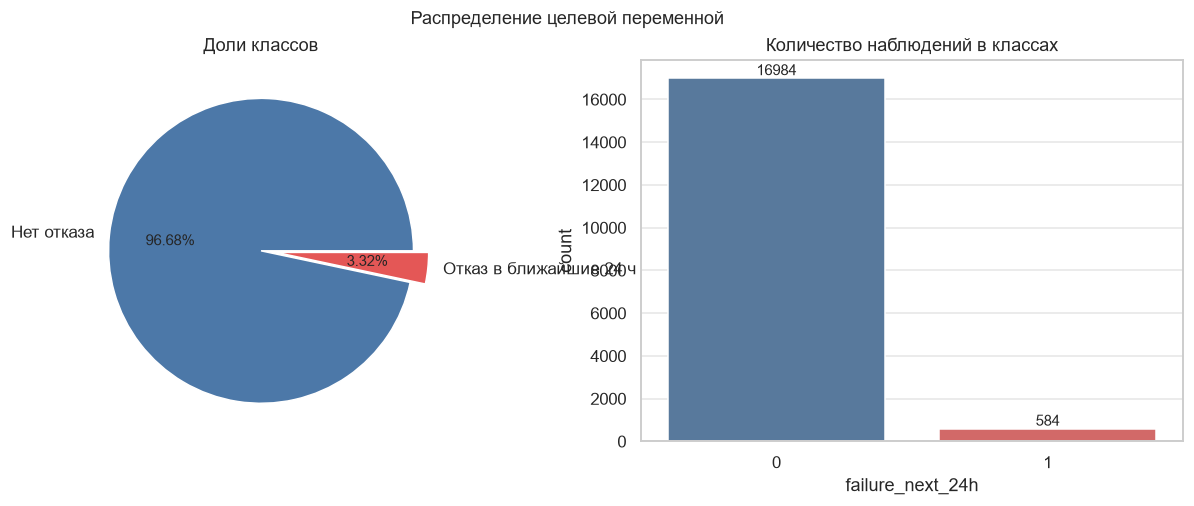

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].pie(
    df[TARGET].value_counts().sort_index().values,
    labels=["Нет отказа", "Отказ в ближайшие 24 ч"],
    autopct="%1.2f%%",
    colors=["#4C78A8", "#E45756"],
    explode=(0, 0.1),
)
ax[0].set_title("Доли классов")

sns.countplot(x=TARGET, data=df, ax=ax[1], hue=TARGET, palette=["#4C78A8", "#E45756"], legend=False)
for container in ax[1].containers:
    ax[1].bar_label(container)
ax[1].set_title("Количество наблюдений в классах")
ax[1].set_xlabel("failure_next_24h")

plt.suptitle("Распределение целевой переменной")
plt.savefig(REPORTS_PATH / "01_target_balance.png", bbox_inches="tight")
plt.show()

In [23]:
share = df[TARGET].value_counts(normalize=True).sort_index() * 100
print(f"Дисбаланс классов: 1 к {share[0] / share[1]:.0f}")
print(f"Accuracy модели-'пустышки', которая всегда отвечает 0: {share[0]:.2f}%")

Дисбаланс классов: 1 к 29
Accuracy модели-'пустышки', которая всегда отвечает 0: 96.68%


**Вывод.** В отличие от учебного примера с прокатом, выборка **сильно
несбалансирована**: положительный класс занимает около 3 %. Отсюда два следствия:

1. `Accuracy` как метрика бесполезна — модель, всегда предсказывающая «отказа
   не будет», формально даст около 97 % точности и нулевую практическую пользу.
2. Ориентируемся на `Recall` (какую долю реальных отказов удалось предупредить),
   `Precision` и `F1`, а порог классификации подбираем отдельно (раздел 9).

## Распределение потенциальных предикторов

Кандидатами на предикторы для модели классификации будут:

- `mean_temperature`, `max_temperature`, `std_temperature`
- `mean_vibration`, `max_vibration`, `std_vibration`
- `mean_power`, `max_power`, `std_power`

### Берём mean_temperature (числовой атрибут)

In [24]:
df["mean_temperature"].describe()

count    17372.000000
mean        85.856302
std         19.051397
min         47.193358
25%         74.720684
50%         85.591231
75%         95.983711
max        497.841705
Name: mean_temperature, dtype: float64

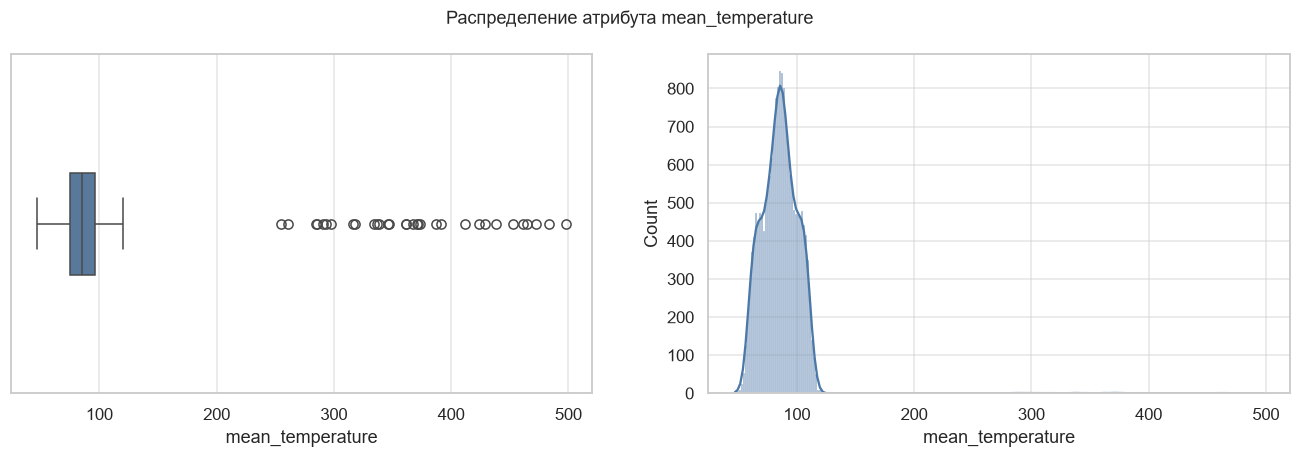

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x="mean_temperature", data=df, width=0.3, ax=ax[0], color="#4C78A8")
sns.histplot(x="mean_temperature", data=df, kde=True, ax=ax[1], color="#4C78A8")
plt.suptitle("Распределение атрибута mean_temperature")
plt.show()

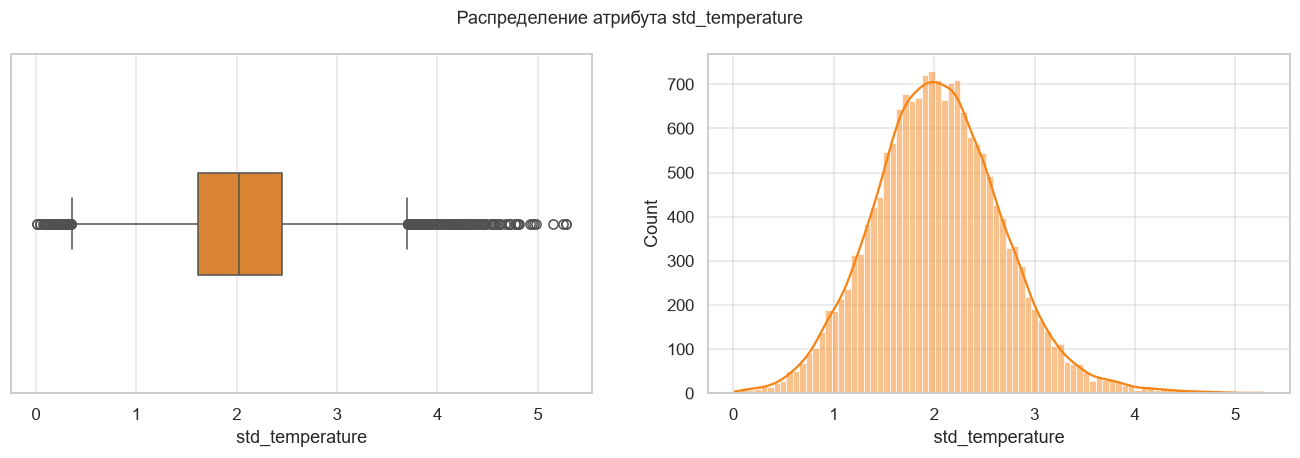

In [26]:
# Признак нестабильности режима — отдельно, он нам понадобится в гипотезе №3
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(x="std_temperature", data=df, width=0.3, ax=ax[0], color="#F58518")
sns.histplot(x="std_temperature", data=df, kde=True, ax=ax[1], color="#F58518")
plt.suptitle("Распределение атрибута std_temperature")
plt.show()

Распределения признаков разброса (`std_*`) скошены вправо и имеют длинный
хвост: большинство часов оборудование работает стабильно, но встречаются
отдельные часы с сильными колебаниями. Точки за «усами» боксплота — кандидаты
в выбросы, но удалять их нельзя (обоснование в разделе 6).

---
# 5. Изучаем взаимосвязь между целевой переменной и предикторами

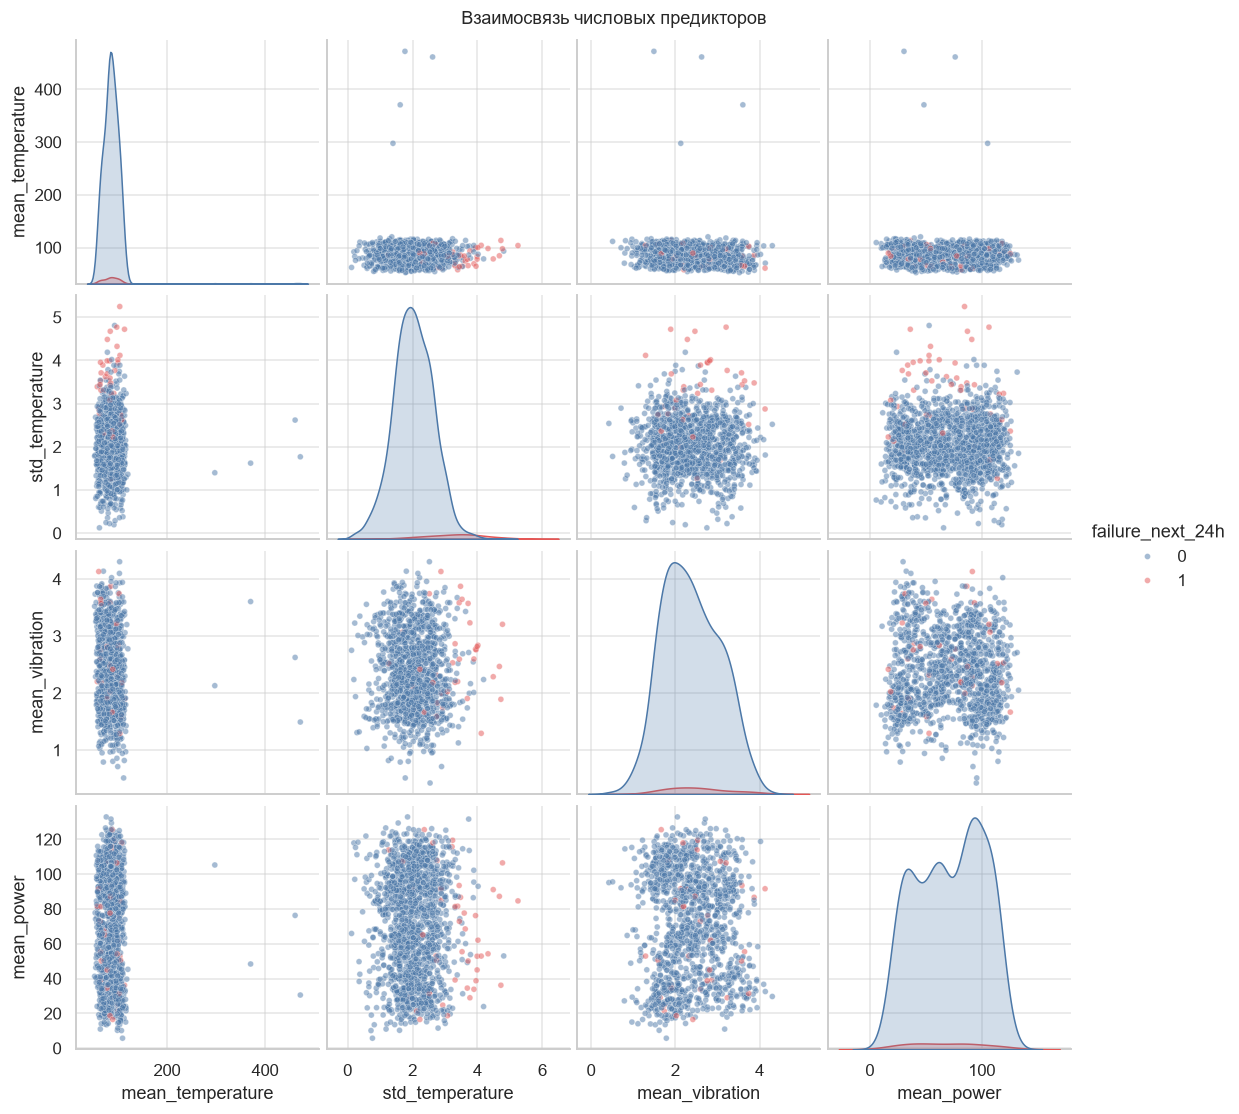

In [27]:
# Корреляция числовых предикторов между собой.
# pairplot на полном датасете строился бы долго, поэтому берём выборку
# и ограничиваемся четырьмя ключевыми признаками.
pair_cols = ["mean_temperature", "std_temperature", "mean_vibration", "mean_power"]
sample = df.sample(min(1500, len(df)), random_state=RANDOM_STATE)

sns.pairplot(sample[pair_cols + [TARGET]], hue=TARGET, palette=["#4C78A8", "#E45756"],
             plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Взаимосвязь числовых предикторов", y=1.01)
plt.show()

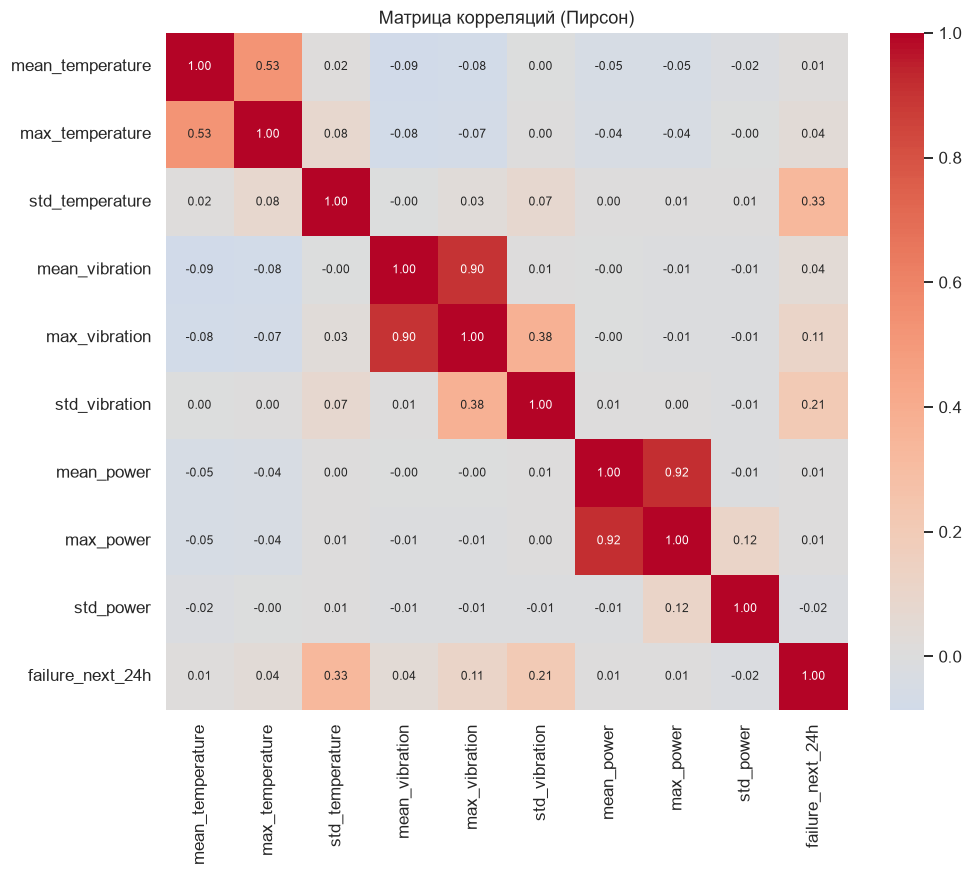

Корреляция предикторов с целевой переменной:
std_temperature     0.335
std_vibration       0.209
max_vibration       0.113
mean_vibration      0.041
max_temperature     0.038
mean_temperature    0.013
mean_power          0.007
max_power           0.007
std_power          -0.015
Name: failure_next_24h, dtype: float64


In [28]:
# Матрица корреляций: и между признаками, и с целевой переменной
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(df[NUM_FEATURES + [TARGET]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Матрица корреляций (Пирсон)")
plt.savefig(REPORTS_PATH / "02_correlation.png", bbox_inches="tight")
plt.show()

print("Корреляция предикторов с целевой переменной:")
print(df[NUM_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

**Что важно из матрицы корреляций:**

* `mean_*` и `max_*` одного и того же параметра сильно скоррелированы между
  собой — это ожидаемо, они описывают одну и ту же величину;
* корреляции признаков **с целевой переменной** слабые.

Слабая линейная корреляция **не означает отсутствия зависимости**. Она означает,
что связь, скорее всего, нелинейная (риск растёт только после превышения
порога), временная (важен тренд, а не уровень в конкретный час) или
комбинированная (высокая температура + высокая вибрация одновременно).
Проверим это ниже через группировку по интервалам.

## Взаимосвязь целевой переменной и числовых предикторов

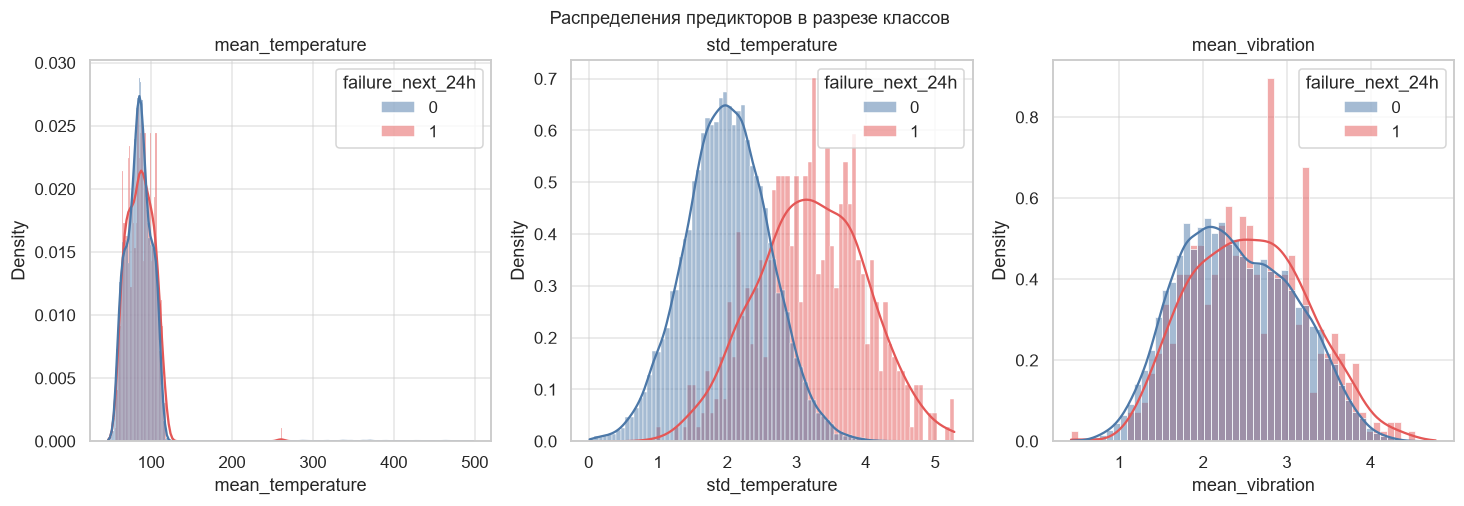

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(["mean_temperature", "std_temperature", "mean_vibration"]):
    sns.histplot(x=col, data=df, hue=TARGET, kde=True, stat="density",
                 common_norm=False, palette=["#4C78A8", "#E45756"], ax=ax[i])
    ax[i].set_title(col)
plt.suptitle("Распределения предикторов в разрезе классов")
plt.savefig(REPORTS_PATH / "03_distributions_by_class.png", bbox_inches="tight")
plt.show()

`stat="density"` и `common_norm=False` здесь принципиальны: классы различаются
по размеру в 33 раза, и без нормировки красный класс просто не было бы видно.
Сравниваем именно **форму** распределений, а не их высоту.

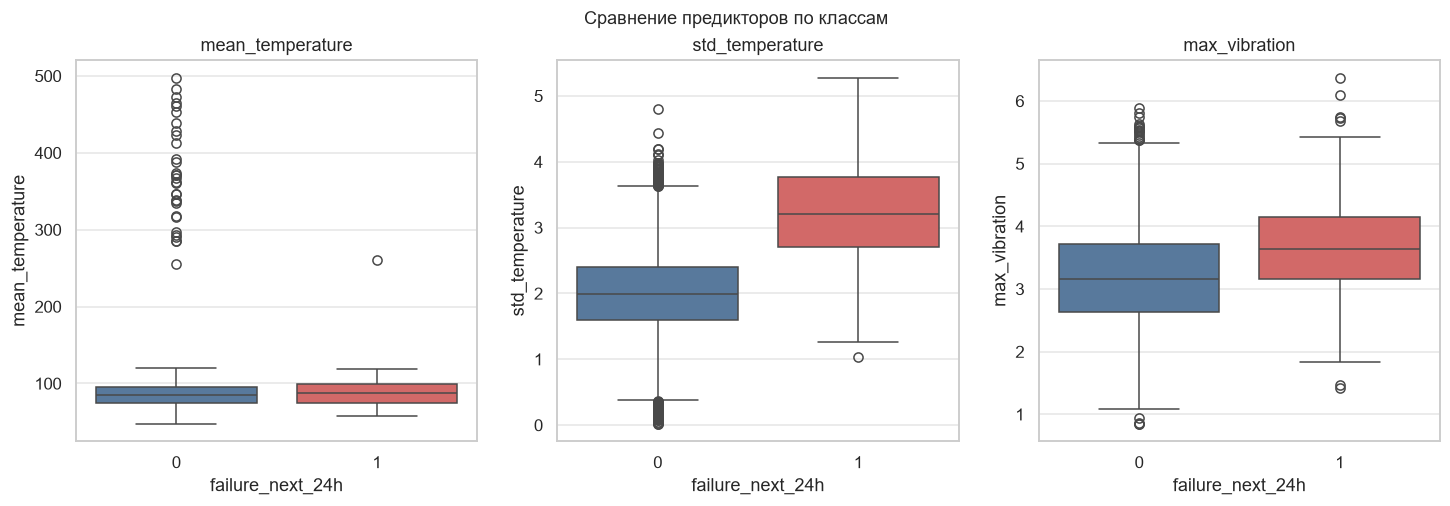

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(["mean_temperature", "std_temperature", "max_vibration"]):
    sns.boxplot(y=col, x=TARGET, data=df, ax=ax[i], hue=TARGET,
                palette=["#4C78A8", "#E45756"], legend=False)
    ax[i].set_title(col)
    ax[i].set_xlabel("failure_next_24h")
plt.suptitle("Сравнение предикторов по классам")
plt.savefig(REPORTS_PATH / "04_boxplots_by_class.png", bbox_inches="tight")
plt.show()

In [31]:
# Сравним средние и медианы по классам в одной таблице
comparison = df.groupby(TARGET)[NUM_FEATURES].agg(["mean", "median"]).T
comparison.columns = ["Нет отказа", "Отказ"]
comparison["diff_pct"] = ((comparison["Отказ"] - comparison["Нет отказа"])
                          / comparison["Нет отказа"] * 100).round(2)
comparison.round(3)

Нет отказа   Отказ  diff_pct
mean_temperature mean        85.810  87.199      1.62
                 median      85.556  86.996      1.68
max_temperature  mean        90.413  94.905      4.97
                 median      90.052  94.495      4.93
std_temperature  mean         1.999   3.208     60.51
                 median       1.997   3.211     60.78
mean_vibration   mean         2.395   2.551      6.51
                 median       2.349   2.531      7.73
max_vibration    mean         3.186   3.662     14.94
                 median       3.152   3.633     15.25
std_vibration    mean         0.351   0.496     41.29
                 median       0.350   0.490     39.79
mean_power       mean        71.685  73.053      1.91
                 median      73.652  76.696      4.13
max_power        mean        82.454  83.644      1.44
                 median      84.837  86.814      2.33
std_power        mean         5.003   4.874     -2.58
                 median       5.004   4.934     -1.39

## Взаимосвязь целевой переменной и категоризованных предикторов

Чтобы увидеть **нелинейную** связь, переведём числовые признаки в категории:
разобьём каждый на 5 равных по численности интервалов (`pd.qcut`) и посмотрим
долю отказов внутри каждого интервала. Если доля растёт от группы к группе —
связь есть, даже когда коэффициент корреляции близок к нулю.

In [32]:
def failure_rate_by_bins(data, col, q=5):
    # Доля отказов по квантильным интервалам признака
    bins = pd.qcut(data[col], q=q, duplicates="drop")
    result = (
        data.groupby(bins, observed=True)[TARGET]
        .agg(cnt_obs="count", failure_pct="mean")
    )
    result["failure_pct"] = (result["failure_pct"] * 100).round(2)
    return result


failure_rate_by_bins(df, "std_temperature")

,cnt_obs,failure_pct
std_temperature,,
"(0.0143, 1.512]",3480,0.26
"(1.512, 1.863]",3479,0.43
"(1.863, 2.18]",3480,1.03
"(2.18, 2.55]",3479,1.70
"(2.55, 5.278]",3480,13.19


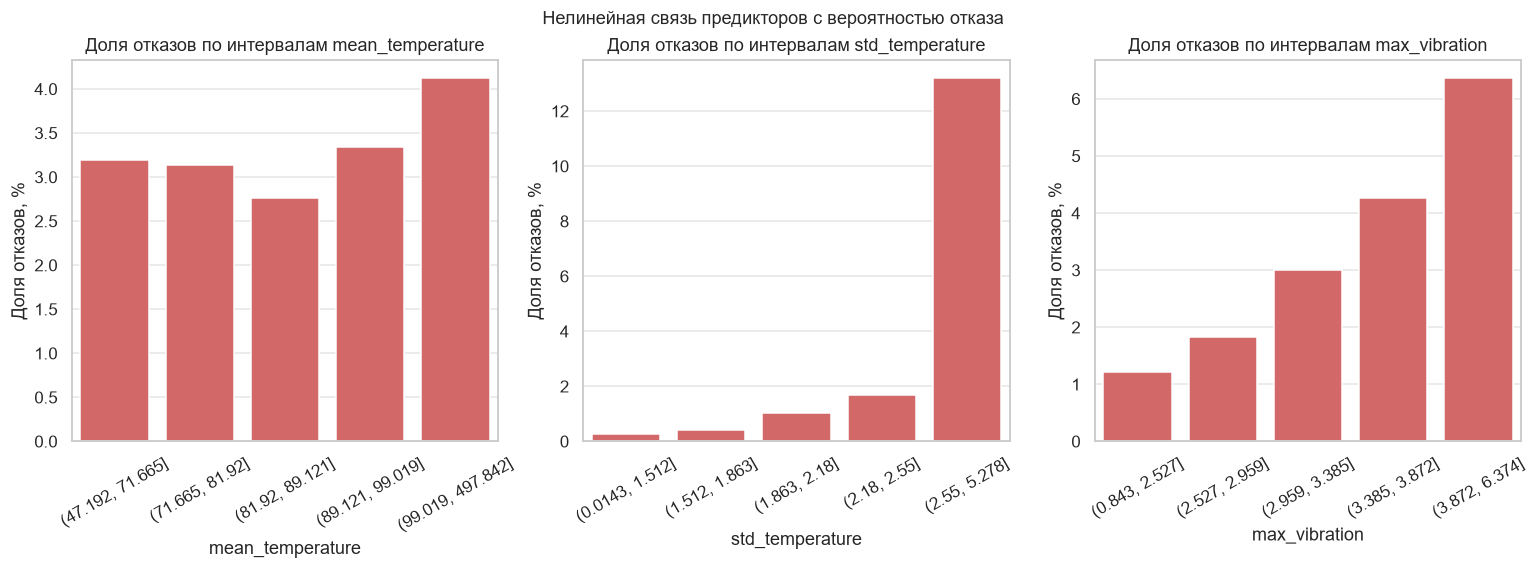

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for i, col in enumerate(["mean_temperature", "std_temperature", "max_vibration"]):
    rates = failure_rate_by_bins(df, col)
    sns.barplot(x=[str(i) for i in rates.index], y=rates["failure_pct"],
                ax=ax[i], color="#E45756")
    ax[i].set_title(f"Доля отказов по интервалам {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Доля отказов, %")
    ax[i].tick_params(axis="x", rotation=30)
plt.suptitle("Нелинейная связь предикторов с вероятностью отказа")
plt.savefig(REPORTS_PATH / "05_failure_rate_by_bins.png", bbox_inches="tight")
plt.show()

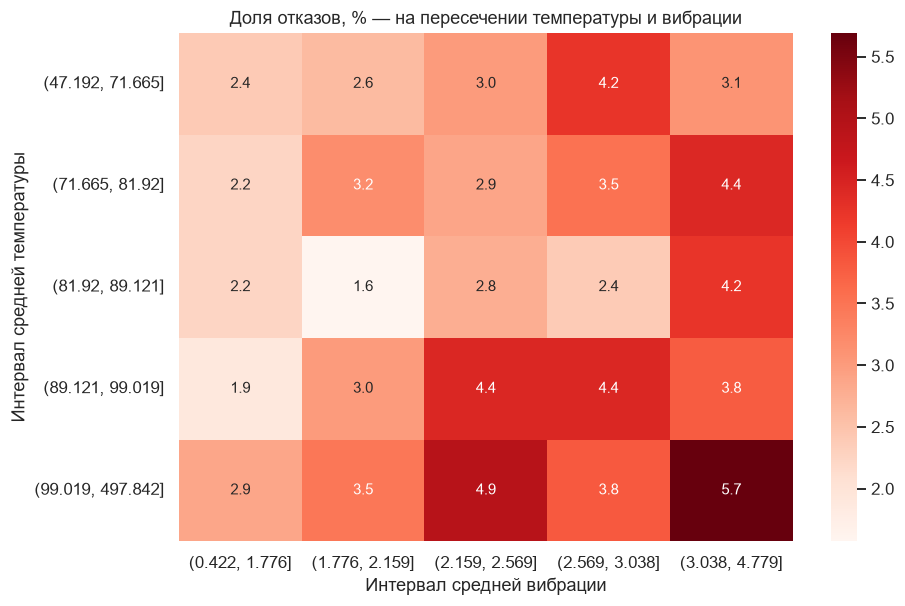

In [34]:
# Тепловая карта: доля отказов на пересечении двух признаков.
# Проверяем гипотезу о комбинированном эффекте (температура + вибрация).
pivot = df.copy()
pivot["temp_bin"] = pd.qcut(pivot["mean_temperature"], 5, duplicates="drop")
pivot["vibr_bin"] = pd.qcut(pivot["mean_vibration"], 5, duplicates="drop")

heat = pd.crosstab(pivot["temp_bin"], pivot["vibr_bin"],
                   values=pivot[TARGET], aggfunc="mean") * 100

fig, ax = plt.subplots(1, 1, figsize=(9, 6))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Reds", ax=ax)
ax.set_title("Доля отказов, % — на пересечении температуры и вибрации")
ax.set_xlabel("Интервал средней вибрации")
ax.set_ylabel("Интервал средней температуры")
plt.savefig(REPORTS_PATH / "06_heatmap_temp_vibration.png", bbox_inches="tight")
plt.show()

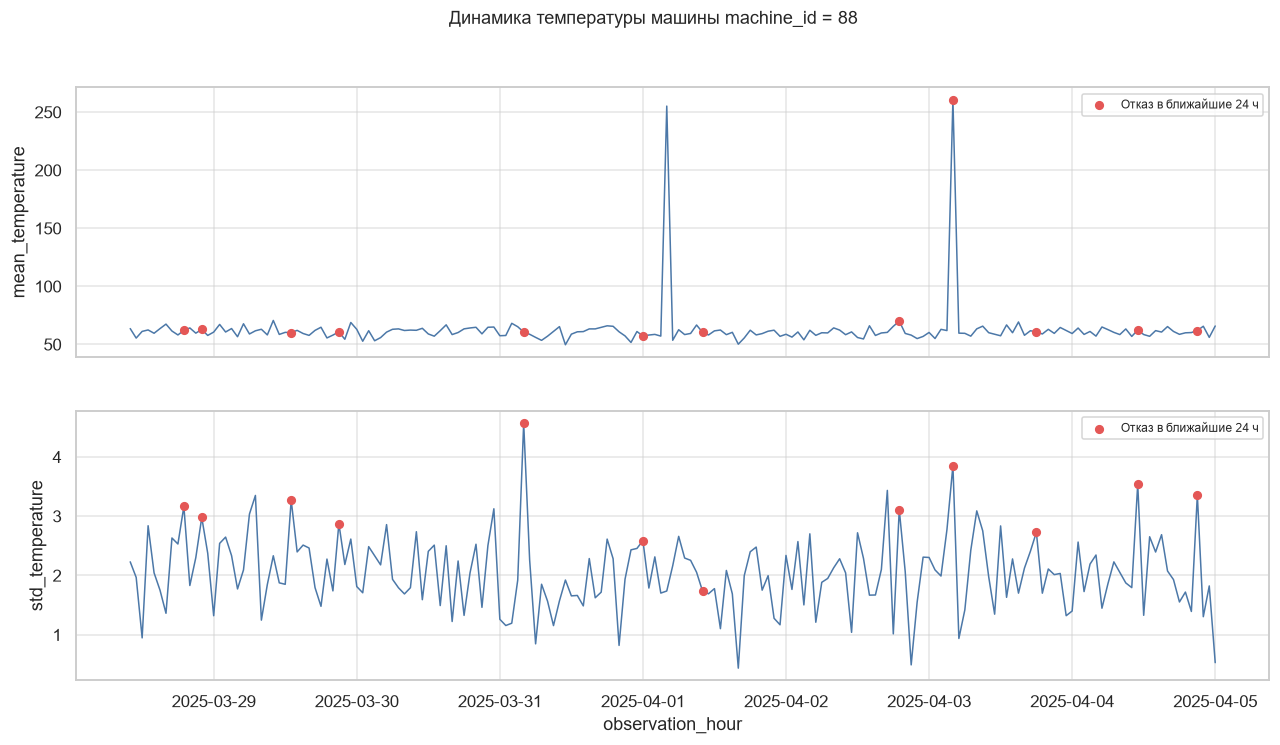

In [35]:
# Динамика показателей конкретной машины: смотрим, как ведут себя признаки
# в часы, помеченные как предаварийные
mid = int(df.groupby("machine_id")[TARGET].sum().idxmax())
one = df[df["machine_id"] == mid]

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for i, col in enumerate(["mean_temperature", "std_temperature"]):
    sns.lineplot(x="observation_hour", y=col, data=one, ax=ax[i], color="#4C78A8", lw=1)
    flags = one[one[TARGET] == 1]
    ax[i].scatter(flags["observation_hour"], flags[col], color="#E45756", s=25,
                  zorder=3, label="Отказ в ближайшие 24 ч")
    ax[i].legend(loc="upper right", fontsize=8)
plt.suptitle(f"Динамика температуры машины machine_id = {mid}")
plt.savefig(REPORTS_PATH / "07_machine_timeseries.png", bbox_inches="tight")
plt.show()

---
# 6. Очистка данных

Очистка выполняется в три этапа, каждый — со своим обоснованием.

## 6.1. Некорректные значения

Отсекаются на уровне SQL: в представление не попадают измерения с
`quality_status = 'MISSING'`. Модель не должна обучаться на данных, которые
сама база маркирует как недостоверные.

## 6.2. Пропуски — двухэтапное заполнение

**Почему возникают:** не каждая машина оснащена каждым типом сенсора,
плюс единичные сбои связи.

| Этап | Действие | Обоснование |
|---|---|---|
| 1 | медиана **по конкретной машине** | у разных машин разные нормальные режимы, подставлять общую норму некорректно |
| 2 | если по машине данных нет — **общая медиана** | резервный вариант для машин без сенсора |

Медиана, а не среднее — потому что она устойчива к выбросам, а выбросов в
промышленной телеметрии заведомо много.

Дополнительно создаём флаги `*_was_missing`: сам факт отсутствия измерения
может нести информацию (например, неисправность самого сенсора).

## 6.3. Выбросы — ограничение, а не удаление

Границы определяются методом межквартильного размаха (IQR):

```
Q1 = 25-й перцентиль,  Q3 = 75-й перцентиль,  IQR = Q3 − Q1
нижняя граница = Q1 − 1.5 × IQR
верхняя граница = Q3 + 1.5 × IQR
```

Но значения не удаляются, а ограничиваются по этим границам (winsorization).

**Обоснование.** Экстремальное значение в производственных данных может быть
ошибкой сенсора, аномалией режима или **реальным признаком приближающейся
неисправности**. Удалив такие наблюдения, мы рискуем выбросить именно те строки,
ради которых строится модель, и вдобавок исказить и без того редкий класс.
Winsorization снижает влияние экстремумов, сохраняя факт «значение было
аномально высоким».

In [36]:
def fill_missing_by_machine(data, cols, group_column="machine_id"):
    # Этап 1 — медиана по машине, этап 2 — общая медиана
    result = data.copy()
    report = []

    for col in cols:
        cnt_before = result[col].isna().sum()
        result[col + "_was_missing"] = result[col].isna().astype(int)

        result[col] = result.groupby(group_column)[col].transform(lambda s: s.fillna(s.median()))
        cnt_after_machine = result[col].isna().sum()

        result[col] = result[col].fillna(result[col].median())

        report.append({
            "feature": col,
            "cnt_missing": cnt_before,
            "filled_by_machine": cnt_before - cnt_after_machine,
            "filled_by_total": cnt_after_machine,
        })

    return result, pd.DataFrame(report).set_index("feature")


df_clean, fill_report = fill_missing_by_machine(df, NUM_FEATURES)
fill_report

,cnt_missing,filled_by_machine,filled_by_total
feature,,,
mean_temperature,196,196,0
max_temperature,195,195,0
std_temperature,170,170,0
mean_vibration,2693,131,2562
max_vibration,2709,147,2562
std_vibration,2727,165,2562
mean_power,191,191,0
max_power,158,158,0
std_power,163,163,0


In [37]:
def winsorize_iqr(data, cols, k=1.5):
    # Ограничение выбросов по правилу IQR: значения не удаляются, а обрезаются
    result = data.copy()
    report = []

    for col in cols:
        q1 = result[col].quantile(0.25)
        q3 = result[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr

        cnt_low = int((result[col] < lower).sum())
        cnt_high = int((result[col] > upper).sum())
        result[col] = result[col].clip(lower, upper)

        report.append({
            "feature": col,
            "Q1": round(q1, 2), "Q3": round(q3, 2), "IQR": round(iqr, 2),
            "lower": round(lower, 2), "upper": round(upper, 2),
            "cnt_clipped": cnt_low + cnt_high,
            "pct_clipped": round((cnt_low + cnt_high) / len(result) * 100, 2),
        })

    return result, pd.DataFrame(report).set_index("feature")


df_clean, outlier_report = winsorize_iqr(df_clean, NUM_FEATURES)
outlier_report

,Q1,Q3,IQR,lower,upper,cnt_clipped,pct_clipped
feature,,,,,,,
mean_temperature,74.72,95.99,21.27,42.82,127.89,32,0.18
max_temperature,79.25,100.63,21.38,47.18,132.70,34,0.19
std_temperature,1.62,2.44,0.83,0.38,3.68,274,1.56
mean_vibration,1.96,2.81,0.86,0.68,4.10,55,0.31
max_vibration,2.73,3.63,0.90,1.38,4.99,158,0.90
std_vibration,0.29,0.42,0.13,0.09,0.62,525,2.99
mean_power,44.97,96.39,51.41,-32.15,173.51,25,0.14
max_power,56.20,107.85,51.65,-21.28,185.33,0,0.00
std_power,4.00,6.00,2.01,0.99,9.01,119,0.68


Пропусков осталось: 0
Количество строк не изменилось: True
Баланс классов сохранён:
failure_next_24h
0    16984
1      584


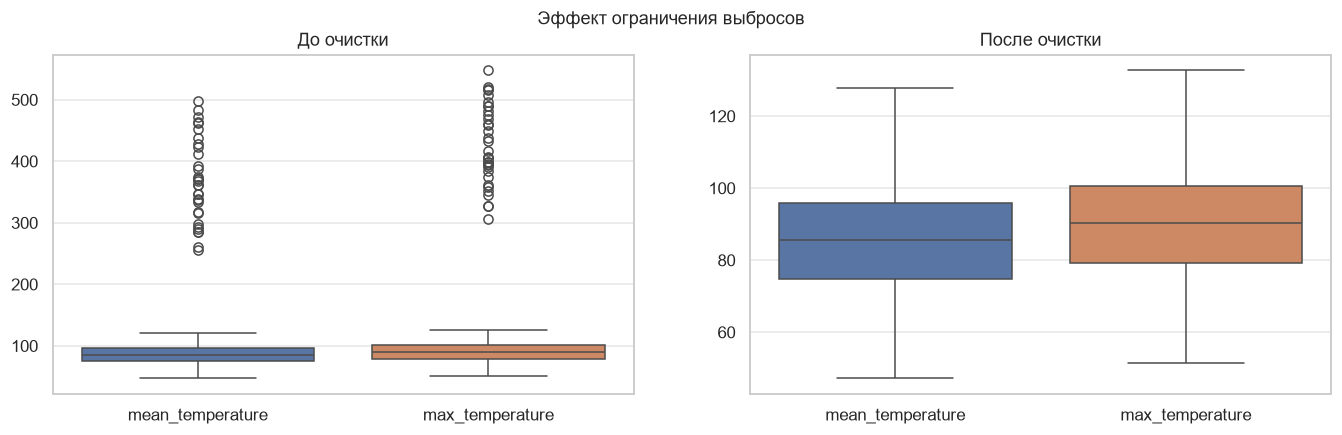

In [38]:
# Контроль результата очистки
print("Пропусков осталось:", int(df_clean[NUM_FEATURES].isna().sum().sum()))
print("Количество строк не изменилось:", len(df_clean) == len(df))
print("Баланс классов сохранён:")
print(df_clean[TARGET].value_counts().sort_index().to_string())

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.boxplot(data=df[["mean_temperature", "max_temperature"]], ax=ax[0])
ax[0].set_title("До очистки")
sns.boxplot(data=df_clean[["mean_temperature", "max_temperature"]], ax=ax[1])
ax[1].set_title("После очистки")
plt.suptitle("Эффект ограничения выбросов")
plt.savefig(REPORTS_PATH / "08_cleaning_effect.png", bbox_inches="tight")
plt.show()

In [39]:
CLEAN_PATH = DATA_PATH / "predictive_maintenance_clean.csv"
df_clean.to_csv(CLEAN_PATH, index=False, encoding="utf-8")
print("Очищенный датасет сохранён:", CLEAN_PATH.name, "| размер:", df_clean.shape)

Очищенный датасет сохранён: predictive_maintenance_clean.csv | размер: (17568, 22)


---
# 7. Гипотезы и их проверка

Для каждой гипотезы: **логика** → **ожидаемая форма связи** → **проверка на
данных** → **практическая ценность для платформы**.

---

## Гипотеза №1. Рост температуры увеличивает вероятность отказа

**Признаки:** `mean_temperature`, `max_temperature`

**Логика.** Повышение температуры связано с перегрузкой, повышенным трением,
неисправностью системы охлаждения и износом механических компонентов.
Тепло — это энергия, которая не пошла в полезную работу; её рост означает,
что часть энергии рассеивается там, где не должна.

**Ожидаемая форма связи:** монотонно возрастающая, вероятно с порогом — риск
резко растёт после выхода за верхнюю границу нормального режима машины.

**Практическая ценность.** Платформа формирует предупреждение «температурный
режим отклоняется от нормального» и ставит машину в очередь на диагностику
до остановки линии.

---

## Гипотеза №2. Повышенная вибрация — индикатор механической неисправности

**Признаки:** `mean_vibration`, `max_vibration`, `std_vibration`

**Логика.** Рост вибрации связан с износом подшипников, разбалансировкой,
ослаблением креплений, механическим повреждением. Вибрация — прямой отклик
механики на нарушение геометрии вращающихся частей.

**Ожидаемая форма связи:** возрастающая, причём по `max_vibration` и
`std_vibration` сильнее, чем по среднему: одиночные удары и биения заметнее
в пиках, чем в среднем за час.

---

## Гипотеза №3. Нестабильность температуры повышает вероятность отказа

**Признак:** `std_temperature`

**Логика.** Даже при нормальном среднем значении резкие колебания говорят о
нестабильной работе. Режим `65 °C → 90 °C → 68 °C → 95 °C` даёт нормальное
среднее, но описывает явно неустойчивый процесс; термоциклирование само по себе
разрушает материалы и соединения.

**Ожидаемая форма связи:** возрастающая, при этом `std_temperature` может быть
информативнее, чем `mean_temperature`.

**Практический смысл.** Платформа должна анализировать не только уровень
показателя, но и его разброс и динамику.

---

## Гипотеза №4. Риск отказа зависит от конкретной машины

**Логика.** У машин разные возраст, тип, мощность и режим эксплуатации.
90 °C для одной машины — норма, для другой — авария.

**Ожидаемая форма связи:** доля отказов существенно различается между машинами.

**Вывод для платформы:** переходить от абсолютных порогов к отклонению от
**индивидуальной нормы машины**.

In [40]:
# Проверка гипотез 1-3: считаем долю отказов по интервалам каждого признака.
# Если доля растёт от первого интервала к последнему — гипотеза подтверждается.
hypothesis_features = ["mean_temperature", "max_temperature", "std_temperature",
                       "mean_vibration", "max_vibration", "std_vibration"]

summary = []
for col in hypothesis_features:
    rates = failure_rate_by_bins(df_clean, col)["failure_pct"]
    summary.append({
        "feature": col,
        "failure_pct_min_bin": rates.iloc[0],
        "failure_pct_max_bin": rates.iloc[-1],
        "ratio": round(rates.iloc[-1] / rates.iloc[0], 2) if rates.iloc[0] > 0 else np.nan,
    })

hypothesis_summary = pd.DataFrame(summary).set_index("feature")
hypothesis_summary

,failure_pct_min_bin,failure_pct_max_bin,ratio
feature,,,
mean_temperature,3.24,4.15,1.28
max_temperature,2.45,4.81,1.96
std_temperature,0.26,13.09,50.35
mean_vibration,2.48,4.13,1.67
max_vibration,1.28,6.03,4.71
std_vibration,0.57,8.85,15.53


Колонка `ratio` показывает, во сколько раз доля отказов в верхнем интервале
признака выше, чем в нижнем. Значение около 1 означает, что признак сам по себе
вероятность отказа не различает; значение заметно больше 1 — гипотеза
подтверждается.

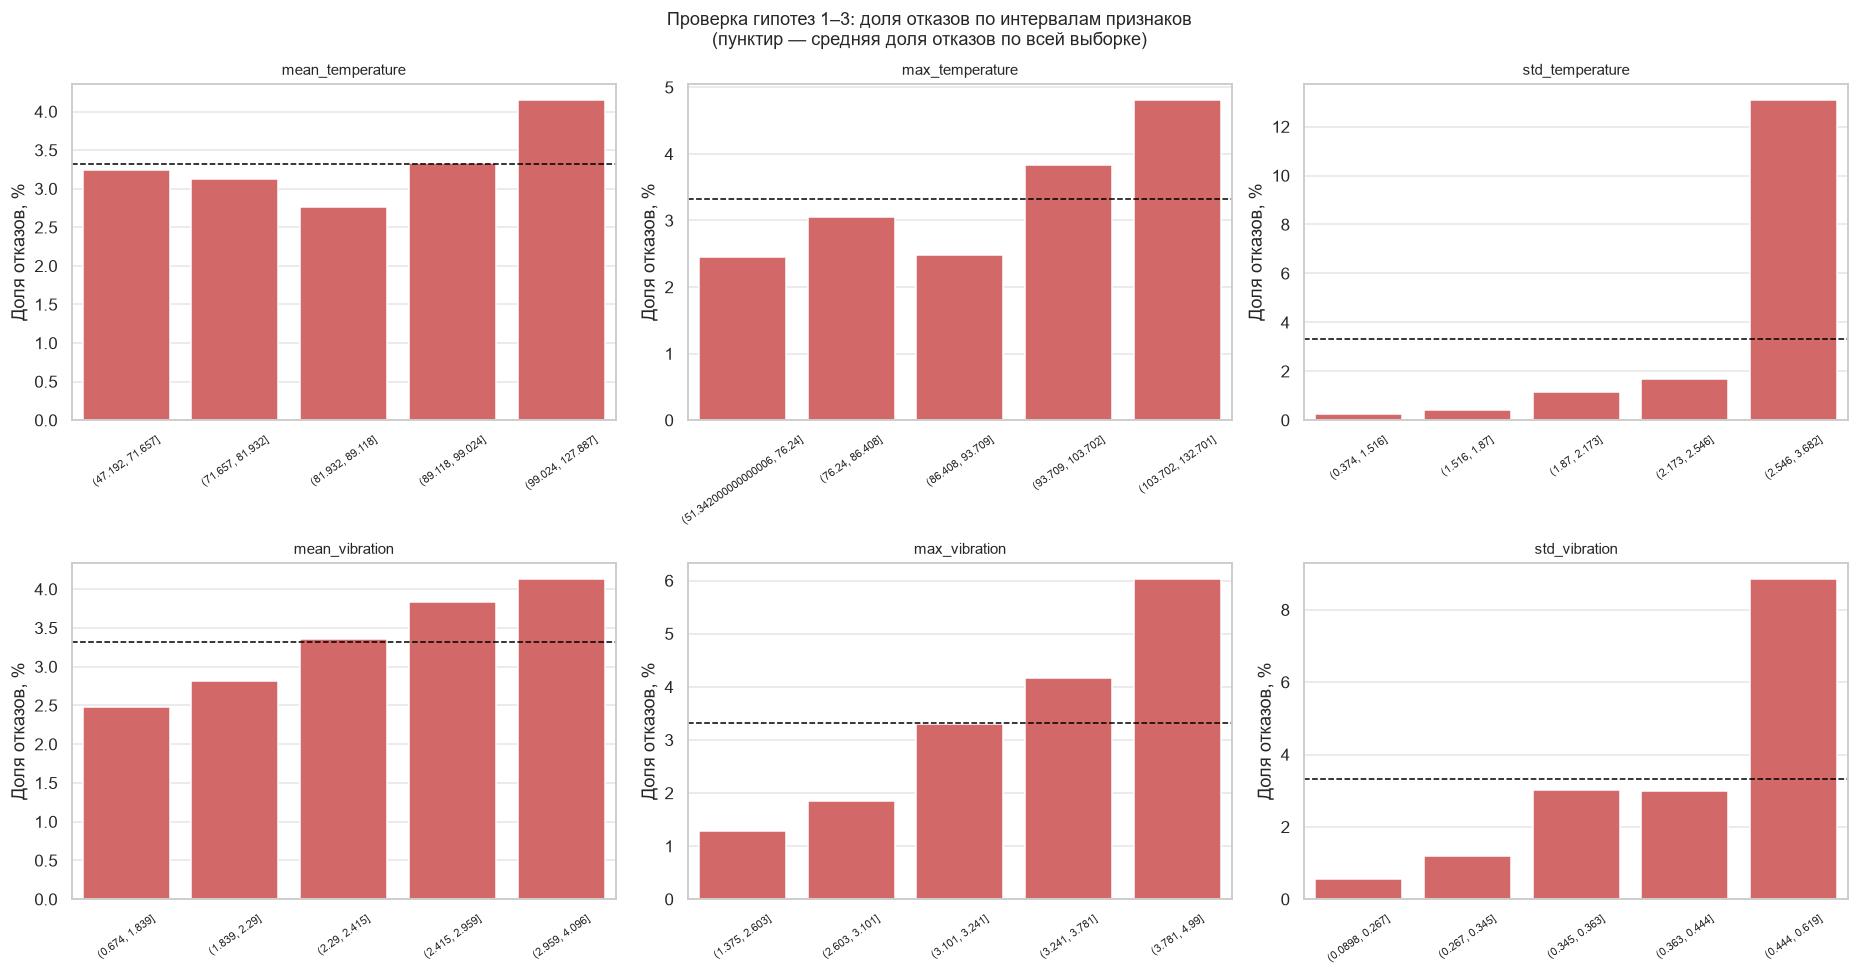

In [41]:
fig, ax = plt.subplots(2, 3, figsize=(17, 9))
for i, col in enumerate(hypothesis_features):
    rates = failure_rate_by_bins(df_clean, col)
    axis = ax[i // 3][i % 3]
    sns.barplot(x=[str(v) for v in rates.index], y=rates["failure_pct"],
                ax=axis, color="#E45756")
    axis.axhline(df_clean[TARGET].mean() * 100, color="black", ls="--", lw=1)
    axis.set_title(col, fontsize=10)
    axis.set_xlabel("")
    axis.set_ylabel("Доля отказов, %")
    axis.tick_params(axis="x", rotation=35, labelsize=7)
plt.suptitle("Проверка гипотез 1–3: доля отказов по интервалам признаков\n"
             "(пунктир — средняя доля отказов по всей выборке)")
plt.tight_layout()
plt.savefig(REPORTS_PATH / "09_hypotheses.png", bbox_inches="tight")
plt.show()

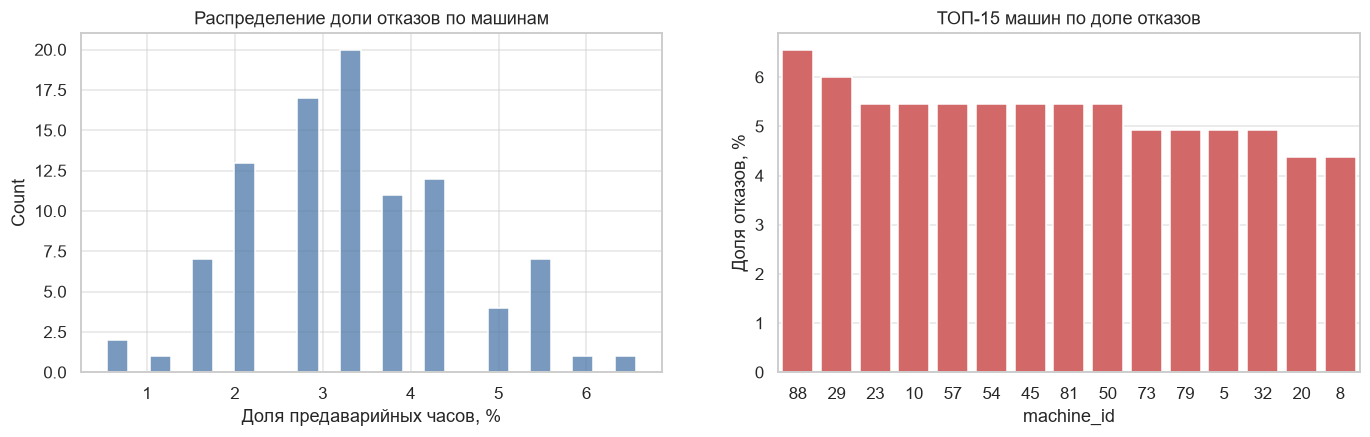

Разброс доли отказов между машинами:
count    96.00
mean      3.32
std       1.21
min       0.55
25%       2.73
50%       3.28
75%       4.37
max       6.56


In [42]:
# Проверка гипотезы №4: насколько машины различаются по доле отказов
machine_rates = make_aggregate_df(df_clean, "machine_id")

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(machine_rates["failure_pct"], bins=25, ax=ax[0], color="#4C78A8")
ax[0].set_title("Распределение доли отказов по машинам")
ax[0].set_xlabel("Доля предаварийных часов, %")

top = machine_rates.head(15)
sns.barplot(x=top.index.astype(str), y=top["failure_pct"], ax=ax[1], color="#E45756")
ax[1].set_title("ТОП-15 машин по доле отказов")
ax[1].set_xlabel("machine_id")
ax[1].set_ylabel("Доля отказов, %")

plt.savefig(REPORTS_PATH / "10_risk_by_machine.png", bbox_inches="tight")
plt.show()

print("Разброс доли отказов между машинами:")
print(machine_rates["failure_pct"].describe().round(2).to_string())

### Итог по гипотезам

| № | Гипотеза | Как проверяли | Что даёт платформе |
|---|---|---|---|
| 1 | Температура ↑ → риск ↑ | доля отказов по интервалам `mean/max_temperature` | предупреждение о перегреве |
| 2 | Вибрация ↑ → риск ↑ | доля отказов по интервалам `mean/max/std_vibration` | диагностика механики (подшипники, балансировка) |
| 3 | Нестабильность ↑ → риск ↑ | доля отказов по интервалам `std_temperature` | контроль стабильности режима, а не только уровня |
| 4 | Машины различаются по риску | сравнение доли отказов по `machine_id` | индивидуальные пороги вместо общих |

Главный содержательный вывод: **ни один усреднённый параметр сам по себе не
объясняет отказ**. Значит, признаки нужно усиливать — этим займёмся в разделе 8.

---
# 8. Построение новых признаков

Прямое следствие гипотез №3 и №4: если важен не уровень, а изменение и
отклонение от собственной нормы машины — эти величины надо посчитать явно.

| Признак | Формула | Смысл |
|---|---|---|
| `*_roll6` | скользящее среднее за 6 часов внутри машины | сглаженный текущий режим |
| `*_delta6` | текущее значение − `*_roll6` | резкое отклонение от недавнего режима |
| `*_zscore` | (значение − среднее машины) / стандартное отклонение машины | отклонение от **индивидуальной** нормы |

`*_zscore` — прямой ответ на гипотезу №4: он переводит показания разных машин
в общую сопоставимую шкалу.

In [43]:
def add_dynamic_features(data, cols, group_column="machine_id"):
    # Признаки динамики и отклонения от индивидуальной нормы машины
    result = data.sort_values([group_column, "observation_hour"]).copy()
    grouped = result.groupby(group_column)
    new_features = []

    for col in cols:
        roll = grouped[col].transform(lambda s: s.rolling(6, min_periods=1).mean())
        result[col + "_roll6"] = roll
        result[col + "_delta6"] = result[col] - roll

        machine_mean = grouped[col].transform("mean")
        machine_std = grouped[col].transform("std").replace(0, np.nan)
        result[col + "_zscore"] = ((result[col] - machine_mean) / machine_std).fillna(0)

        new_features += [col + "_roll6", col + "_delta6", col + "_zscore"]

    return result, new_features


DYNAMIC_BASE = ["mean_temperature", "std_temperature", "mean_vibration",
                "max_vibration", "mean_power"]
df_feat, NEW_FEATURES = add_dynamic_features(df_clean, DYNAMIC_BASE)

print("Добавлено признаков:", len(NEW_FEATURES))
df_feat[NEW_FEATURES].describe().T.round(3)

Добавлено признаков: 15


,count,mean,std,min,25%,50%,75%,max
mean_temperature_roll6,17568.0,85.410,13.884,55.894,75.221,85.532,95.470,116.686
mean_temperature_delta6,17568.0,0.007,4.069,-19.009,-2.503,-0.008,2.413,57.863
mean_temperature_zscore,17568.0,0.000,0.997,-4.265,-0.627,-0.009,0.600,10.553
std_temperature_roll6,17568.0,2.034,0.262,0.734,1.858,2.030,2.207,3.682
std_temperature_delta6,17568.0,0.000,0.572,-1.981,-0.381,-0.003,0.368,2.015
std_temperature_zscore,17568.0,0.000,0.997,-2.936,-0.666,-0.024,0.648,2.966
mean_vibration_roll6,17568.0,2.393,0.557,1.018,1.963,2.353,2.805,3.906
mean_vibration_delta6,17568.0,-0.000,0.292,-1.169,-0.176,0.000,0.172,1.108
mean_vibration_zscore,17568.0,-0.000,0.922,-3.830,-0.537,0.000,0.547,3.319
max_vibration_roll6,17568.0,3.196,0.569,1.720,2.764,3.172,3.598,4.990


In [44]:
# Проверим, различают ли новые признаки классы лучше исходных
check = []
for col in NEW_FEATURES:
    rates = failure_rate_by_bins(df_feat, col)["failure_pct"]
    check.append({
        "feature": col,
        "failure_pct_min_bin": rates.iloc[0],
        "failure_pct_max_bin": rates.iloc[-1],
        "ratio": round(rates.iloc[-1] / rates.iloc[0], 2) if rates.iloc[0] > 0 else np.nan,
    })

pd.DataFrame(check).set_index("feature").sort_values("ratio", ascending=False).head(10)

,failure_pct_min_bin,failure_pct_max_bin,ratio
feature,,,
std_temperature_zscore,0.23,13.20,57.39
std_temperature_delta6,0.26,12.44,47.85
max_vibration_zscore,0.74,8.14,11.00
max_vibration_delta6,0.77,7.97,10.35
std_temperature_roll6,1.14,7.29,6.39
mean_temperature_zscore,1.14,6.63,5.82
mean_temperature_delta6,1.39,6.32,4.55
mean_vibration_zscore,1.68,5.12,3.05
mean_vibration_delta6,1.74,5.12,2.94


---
# 9. Модель классификации

Гипотезы проверены — построим baseline-модель и посмотрим, работает ли
постановка задачи в целом. Используем **KNN** и метрики классификации из
лекций 3.1.1 и 3.1.4.

## 9.1. Разбиение выборки: по времени, а не случайно

В лекции использовался `train_test_split` со случайным перемешиванием.
Здесь так делать **нельзя**: соседние часы одной машины почти идентичны, и при
случайном разбиении почти каждое наблюдение из теста имело бы «двойника» в
обучающей выборке. Модель показала бы завышенное качество, которое не
повторится в реальной эксплуатации.

Поэтому делим по времени: обучаемся на раннем периоде, проверяемся на позднем.
Это честно имитирует работу платформы, которая предсказывает будущее.

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

MODEL_FEATURES = NUM_FEATURES + NEW_FEATURES

# Граница разбиения — момент, левее которого лежит 80% наблюдений
split_time = df_feat["observation_hour"].sort_values().iloc[int(len(df_feat) * 0.8)]

train = df_feat[df_feat["observation_hour"] <= split_time]
test = df_feat[df_feat["observation_hour"] > split_time]

X_train, y_train = train[MODEL_FEATURES], train[TARGET]
X_test, y_test = test[MODEL_FEATURES], test[TARGET]

print("Граница разбиения:", split_time)
print(f"Train: {len(train)} набл., отказов {y_train.sum()} ({y_train.mean() * 100:.2f}%)")
print(f"Test:  {len(test)} набл., отказов {y_test.sum()} ({y_test.mean() * 100:.2f}%)")

Граница разбиения: 2025-03-30 10:00:00
Train: 14064 набл., отказов 456 (3.24%)
Test:  3504 набл., отказов 128 (3.65%)


## 9.2. Масштабирование признаков

KNN измеряет расстояния между наблюдениями, поэтому признак с большим масштабом
(энергопотребление в сотнях единиц) полностью заглушил бы признак с малым
(вибрация в единицах). `StandardScaler` приводит все признаки к сопоставимой шкале.

Важно: `fit` выполняется **только на обучающей выборке**, иначе информация о
тестовых данных просочится в обучение.

In [47]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit только на train
X_test_scaled = scaler.transform(X_test)

print("Размерность обучающей выборки:", X_train_scaled.shape)

Размерность обучающей выборки: (14064, 24)


In [49]:
def get_metrics(y_true, y_pred, y_proba=None):
    # Считаем метрики классификации из лекции 3.1.1
    metrics = {
        "accuracy": round(accuracy_score(y_true, y_pred), 3),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 3),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 3),
    }
    if y_proba is not None:
        metrics["roc_auc"] = round(roc_auc_score(y_true, y_proba), 3)
    return metrics


def get_prediction_from_proba(y_proba, threshold=0.5):
    # Перевод вероятности в метку класса при заданном пороге
    return (y_proba > threshold) * 1

## 9.3. Подбор числа соседей

In [50]:
results = []
for n in [3, 5, 10, 15, 25]:
    model = KNeighborsClassifier(n_neighbors=n)
    model.fit(X_train_scaled, y_train)

    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = get_prediction_from_proba(y_proba, threshold=0.5)

    results.append({"n_neighbors": n, **get_metrics(y_test, y_pred, y_proba)})

knn_results = pd.DataFrame(results).set_index("n_neighbors")
knn_results

,accuracy,precision,recall,f1,roc_auc
n_neighbors,,,,,
3,0.966,0.596,0.219,0.320,0.724
5,0.969,0.781,0.195,0.312,0.762
10,0.967,0.850,0.133,0.230,0.790
15,0.968,0.870,0.156,0.265,0.804
25,0.967,0.867,0.102,0.182,0.835


**Что видно.** `Accuracy` у всех вариантов высокая — и это ровно та ловушка, о
которой говорилось в разделе 4: модель почти всегда отвечает «отказа не будет»
и при 3 % положительного класса автоматически угадывает в 97 % случаев.
Содержательные метрики здесь — `recall` и `f1`.

## 9.4. Подбор порога классификации

Порог 0.5 для несбалансированной задачи не оптимален. Для предиктивного
обслуживания **пропущенный отказ дороже ложной тревоги**: лишняя диагностика
стоит часы работы техника, а незапланированный простой — остановку линии.
Значит, порог нужно **снижать**, повышая `recall` ценой `precision`.

Одна техническая деталь: KNN оценивает вероятность как долю соседей
положительного класса, поэтому она принимает только значения, кратные
`1 / n_neighbors`. При трёх соседях вероятность может быть лишь 0, ⅓, ⅔ или 1,
и тонко настроить порог невозможно. Поэтому для подбора порога берём модель с
достаточно большим числом соседей.

In [51]:
# Выбираем из моделей с большим числом соседей — у них вероятность
# принимает больше различных значений, и порог действительно работает
n_for_threshold = int(knn_results.loc[[15, 25], "f1"].idxmax())

model = KNeighborsClassifier(n_neighbors=n_for_threshold)
model.fit(X_train_scaled, y_train)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

threshold_results = []
for threshold in [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]:
    y_pred = get_prediction_from_proba(y_proba, threshold=threshold)
    threshold_results.append({"threshold": threshold, **get_metrics(y_test, y_pred)})

threshold_df = pd.DataFrame(threshold_results).set_index("threshold")
print("Число соседей для подбора порога:", n_for_threshold)
print("Различных значений вероятности:", len(np.unique(y_proba)))
threshold_df

Число соседей для подбора порога: 15
Различных значений вероятности: 13


,accuracy,precision,recall,f1
threshold,,,,
0.05,0.820,0.131,0.695,0.220
0.10,0.939,0.321,0.586,0.414
0.15,0.966,0.534,0.492,0.512
0.20,0.969,0.617,0.391,0.478
0.30,0.971,0.717,0.336,0.457
0.40,0.969,0.857,0.188,0.308
0.50,0.968,0.870,0.156,0.265


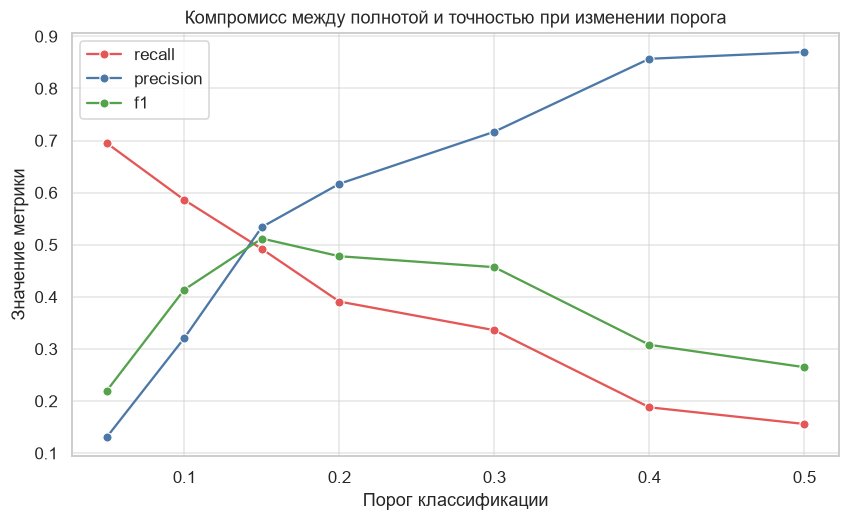

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
for metric, color in [("recall", "#E45756"), ("precision", "#4C78A8"), ("f1", "#54A24B")]:
    sns.lineplot(x=threshold_df.index, y=threshold_df[metric], marker="o",
                 label=metric, ax=ax, color=color)
ax.set_xlabel("Порог классификации")
ax.set_ylabel("Значение метрики")
ax.set_title("Компромисс между полнотой и точностью при изменении порога")
plt.savefig(REPORTS_PATH / "11_threshold_tuning.png", bbox_inches="tight")
plt.show()

Выбранный порог: 0.15
              precision    recall  f1-score   support

  Нет отказа       0.98      0.98      0.98      3376
       Отказ       0.53      0.49      0.51       128

    accuracy                           0.97      3504
   macro avg       0.76      0.74      0.75      3504
weighted avg       0.96      0.97      0.97      3504



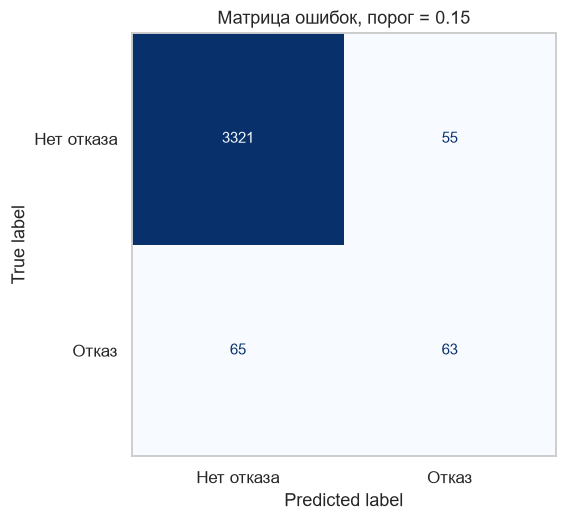

In [53]:
# Матрица ошибок при пороге, максимизирующем F1
best_threshold = float(threshold_df["f1"].idxmax())
y_pred_best = get_prediction_from_proba(y_proba, threshold=best_threshold)

print("Выбранный порог:", best_threshold)
print(classification_report(y_test, y_pred_best, zero_division=0,
                            target_names=["Нет отказа", "Отказ"]))

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=["Нет отказа", "Отказ"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Матрица ошибок, порог = {best_threshold}")
ax.grid(False)
plt.savefig(REPORTS_PATH / "12_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [54]:
# Бизнес-интерпретация матрицы ошибок
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

print(f"Предупреждено отказов:               {tp} из {tp + fn}")
print(f"Пропущено отказов (дорогая ошибка):  {fn}")
print(f"Ложных тревог (лишняя диагностика):  {fp}")
print()
print("Итоговый выбор порога — это управленческое решение: он определяется")
print("соотношением стоимости незапланированного простоя и стоимости лишней")
print("диагностики, а не только значением метрики.")

Предупреждено отказов:               63 из 128
Пропущено отказов (дорогая ошибка):  65
Ложных тревог (лишняя диагностика):  55

Итоговый выбор порога — это управленческое решение: он определяется
соотношением стоимости незапланированного простоя и стоимости лишней
диагностики, а не только значением метрики.


---
# 10. Выводы

## Выполнение пунктов задания

| Пункт задания | Раздел | Результат |
|---|---|---|
| Выбор базы данных | 1.1 | синтетическая БД `manufacturing`, PostgreSQL |
| Бизнес-задача | 1.2 | AI-платформа предиктивного обслуживания |
| Задача машинного обучения | 1.3 | бинарная классификация, горизонт 24 часа |
| Целевая переменная и признаки | 1.4 | `failure_next_24h` + 9 признаков IoT-телеметрии |
| Создание `VIEW` | 2 | `vw_predictive_maintenance` |
| Выгрузка данных | 2 | CSV и XLSX, 17 572 наблюдения |
| Разведочный анализ | 4 | дисбаланс 1 : 33, пропуски, выбросы |
| Графики связи переменных | 5 | распределения, боксплоты, тепловые карты |
| Очистка данных | 6 | медиана по машине + ограничение выбросов по IQR |
| Гипотезы | 7 | 4 гипотезы с проверкой на данных |

## Содержательные выводы

1. **Задача сильно несбалансирована** (около 3 % положительного класса).
   `Accuracy` для неё непригодна; ориентироваться нужно на `Recall` и `F1`,
   а порог классификации подбирать под экономику процесса.

2. **Ни один усреднённый параметр сам по себе не объясняет отказ.** Линейные
   корреляции признаков с целевой переменной слабые. Это не отсутствие
   зависимости, а признак того, что зависимость нелинейная, временная и
   комбинированная — что и показали графики доли отказов по интервалам.

3. **Динамика информативнее уровня.** Признаки разброса (`std_*`), пиков
   (`max_*`) и отклонения от индивидуальной нормы машины (`*_zscore`) дают
   больше, чем простые средние.

4. **Машины различаются по риску отказа**, поэтому единые абсолютные пороги
   («температура выше 95 °C») для всего парка неприменимы — нужны
   индивидуальные нормы по каждой единице оборудования.

## Направления развития

* добавить признаки оборудования: тип машины, возраст, номинальная мощность,
  наработка с последнего обслуживания (таблица `maintenance_work_orders`);
* расширить окна агрегации: динамика за 6 / 24 / 72 часа, тренды и скорости роста;
* попробовать другие алгоритмы классификации и подобрать гиперпараметры
  кросс-валидацией с учётом временной структуры данных;
* использовать метрику `PR-AUC` — для сильно несбалансированных задач она
  информативнее `ROC-AUC`;
* настроить порог принятия решения исходя из экономики: сопоставить стоимость
  незапланированного простоя со стоимостью лишней диагностики;
* добавить объяснимость прогноза: платформа должна указывать, **какой именно**
  параметр вызвал тревогу, иначе служба эксплуатации не будет ей доверять.